<p style="text-align:center"> 
    <a href="https://www.linkedin.com/in/flavio-aguirre-12784a252/" target="_blank"> 
        <img src="../assets/logo.png" width="200" alt="Flavio Aguirre Logo"> 
    </a>
</p>

<h1 align="center"><font size="7"><strong>📉 ByeBye Predictor</strong></font></h1>
<br>
<hr>

## Hybrid Churn Model – Structured + Text Integration

**Date:** November 30, 2025  
**Subject:** Integrating Telco structured churn model with text-based churn intent signals

In previous notebooks we:

- Built a complete **Telco Customer Churn** pipeline using structured features:
  data cleaning, feature engineering, modeling, and evaluation.
- Collected and cleaned **Reddit comments** related to telcos, created a
  heuristic `churn_signal` label, and trained a **text-based churn-intent model**.
- Enriched the Reddit dataset with a **model-based churn risk score**:
  `nlp_churn_score ∈ [0, 1]`.

In this notebook we will:

1. Load the processed **Telco churn dataset**.
2. Simulate **customer-level aggregated features** derived from `nlp_churn_score`
   (e.g., max/mean scores and high-risk interaction counts).
3. Build and compare two churn models using the existing `ModelBuilder`:
   - A **baseline** model using only structured Telco features.
   - A **hybrid** model using structured + synthetic text-based features.
4. Evaluate both models with `ModelEvaluator` (ROC AUC, PR AUC, confusion matrix).
5. Provide a small **end-to-end scoring demo** showing how structured features
   and text aggregates would be combined in production.

The goal is to demonstrate a **rigorous, enterprise-ready hybrid churn modeling
pattern** that combines Telco structured data with text-based churn-intent
signals in a clean and reproducible way.

### Imports and setup

In [1]:
### Imports and setup
from notebooks_setup import PROJECT_ROOT

# Local imports
from src.utils import get_logger
from src.data_loader import load_csv, save_df
from src.eda import plot_numerical_distributions
from src.model_builder import ModelBuilderError, ModelBuilder
from src.model_evaluation import ModelEvaluationError, ModelEvaluator

# External imports
from pathlib import Path
from typing import Dict, Any

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

import joblib
import matplotlib.pyplot as plt
import seaborn as sns

2025-11-30 14:02:14,176 | utils | INFO | Added project root to sys.path: C:\Users\Pc\Desktop\github
2025-11-30 14:02:15,760 | src.model_builder | INFO | ModelBuilder Module initialized successfully!
2025-11-30 14:02:15,767 | src.model_evaluation | INFO | ModelEvaluator Module initialized successfully!


In [2]:
# General configuration
logger = get_logger(__name__)

PROJECT_ROOT = Path(".").resolve()
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / "hybrid-model"
MODELS_DIR = PROJECT_ROOT / "models" / "hybrid-model"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

%matplotlib inline

### Notebook Context

This notebook ties together the two main components of the 📉 **ByeBye Predictor** project:

1. **Structured Telco churn model** (Notebooks 00–05):
   - Classic Telco Customer Churn dataset.
   - Data cleaning, missing value handling, encoding, and scaling.
   - End-to-end churn pipelines with scikit-learn.
   - Evaluation with ROC AUC, PR AUC, confusion matrix, etc.

2. **Text-based churn-intent model** (Notebooks 06–07):
   - Reddit comments about telcos, cleaned using a Spanish `TextCleaner`.
   - Heuristic `churn_signal` labels capturing explicit churn intent.
   - `churn_text_model` built with:
     - `TextCleaner` → TF-IDF (unigrams + bigrams) → TruncatedSVD → LogisticRegression.
   - Enriched dataset with:
     - `nlp_churn_score = churn_text_model.predict_proba(body)[:, 1]`.

In a real-world scenario, each text interaction (ticket, chat, social post) would be
linked to a **customer identifier** and a timestamp. We would then:

- Score each interaction with `churn_text_model` to obtain `nlp_churn_score`.
- Aggregate scores per customer over specific time windows (e.g., last 30/90 days).
- Join these aggregates to the structured Telco features.
- Train a **hybrid churn model** using both structured and text-derived signals.

In this notebook we do not have a real join key between Telco and Reddit, so we:

- **Simulate** customer-level aggregated features that mimic realistic
  `nlp_churn_score` patterns correlated with churn.
- Use the existing `ModelBuilder` and `ModelEvaluator` utilities to:
  - Train and select models.
  - Evaluate performance.
  - Produce plots and comparison tables.

This keeps the hybrid extension fully consistent with the rest of the codebase.

In [3]:
## Load Telco data and quick sanity check

# Curated feature set (already cleaned / encoded, no customerID column)
TELCO_FILENAME = "telco_churn_curated.csv"
telco_path = PROCESSED_DIR / TELCO_FILENAME

logger.info(f"Loading curated Telco dataset from {telco_path}")
telco_df = load_csv(telco_path)

logger.info(f"Telco shape (features only, before merging target): {telco_df.shape}")
logger.info(f"Telco columns: {list(telco_df.columns)}")

# Processed target stored separately
TARGET_FILENAME = "target_processed.csv"
target_path = PROCESSED_DIR / TARGET_FILENAME

logger.info(f"Loading processed target from {target_path}")
target_df = load_csv(target_path)

logger.info(f"Target shape: {target_df.shape}")
logger.info(f"Target columns: {list(target_df.columns)}")

# Assumption:
# - telco_churn_curated.csv and target_processed.csv have rows aligned in the same order.
TARGET_COL = "churn"

if TARGET_COL not in target_df.columns:
    raise KeyError(
        f"Target column '{TARGET_COL}' not found in target_df columns: "
        f"{target_df.columns.tolist()}"
    )

# Align by index (no customerID available)
if len(telco_df) != len(target_df):
    raise ValueError(
        "Mismatch between number of rows in curated features and target_processed.\n"
        f"telco_df rows: {len(telco_df)}, target_df rows: {len(target_df)}"
    )

# Add target as a new column, preserving row order
telco_df[TARGET_COL] = target_df[TARGET_COL].values

logger.info(f"Telco shape after adding target: {telco_df.shape}")

# Ensure binary numeric target
if not pd.api.types.is_numeric_dtype(telco_df[TARGET_COL]):
    raise TypeError(
        f"Target column '{TARGET_COL}' is not numeric after merge. "
        f"Dtype: {telco_df[TARGET_COL].dtype}"
    )

unique_target_values = sorted(telco_df[TARGET_COL].unique().tolist())
logger.info(f"Unique values in target '{TARGET_COL}': {unique_target_values}")

if set(unique_target_values) - {0, 1}:
    raise ValueError(
        f"Target column '{TARGET_COL}' contains values different from 0/1: "
        f"{unique_target_values}"
    )

logger.info("Target (churn) distribution:")
logger.info(telco_df[TARGET_COL].value_counts(normalize=True))

# Quick peek (now without an ID, just show first rows and target)
telco_df.head()

2025-11-30 14:02:15,815 | __main__ | INFO | Loading curated Telco dataset from C:\Users\Pc\Desktop\github\byebye_predictor\data\processed\telco_churn_curated.csv
2025-11-30 14:02:15,848 | src.data_loader | INFO | Loaded CSV: C:\Users\Pc\Desktop\github\byebye_predictor\data\processed\telco_churn_curated.csv | Shape: (7043, 30)
2025-11-30 14:02:15,851 | src.data_loader | INFO | Completed: load_csv
2025-11-30 14:02:15,854 | __main__ | INFO | Telco shape (features only, before merging target): (7043, 30)
2025-11-30 14:02:15,856 | __main__ | INFO | Telco columns: ['monthly_charges', 'tenure', 'total_charges', 'gender_male', 'partner_yes', 'dependents_yes', 'phone_service_yes', 'multiple_lines_no_phone_service', 'multiple_lines_yes', 'internet_service_fiber_optic', 'internet_service_no', 'online_security_no_internet_service', 'online_security_yes', 'online_backup_no_internet_service', 'online_backup_yes', 'device_protection_no_internet_service', 'device_protection_yes', 'tech_support_no_inte

,monthly_charges,tenure,total_charges,gender_male,partner_yes,dependents_yes,phone_service_yes,multiple_lines_no_phone_service,multiple_lines_yes,internet_service_fiber_optic,...,streaming_movies_no_internet_service,streaming_movies_yes,contract_one_year,contract_two_year,paperless_billing_yes,payment_method_credit_card_automatic,payment_method_electronic_check,payment_method_mailed_check,senior_citizen,churn
0,-1.160323,-1.277445,-0.994242,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0
1,-0.259629,0.066327,-0.173244,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0
2,-0.362660,-1.236724,-0.959674,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1
3,-0.746535,0.514251,-0.194766,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,0.197365,-1.236724,-0.940470,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1


### Context: Reddit Churn Intent and `nlp_churn_score`

In Notebook 07 we:

- Trained `churn_text_model` on labeled Reddit comments with a heuristic
  `churn_signal` label.
- Evaluated the model (classification report, ROC AUC, PR AUC, confusion matrix).
- Generated `nlp_churn_score` for each comment:
  - `nlp_churn_score = churn_text_model.predict_proba(body)[:, 1]`
- Saved the enriched dataset as:
  - `data/processed/reddit_comments_with_nlp_score_*.csv`.

In production, the workflow would be:

1. Maintain an **interactions table**:
   - `(customerID, text, timestamp, channel, ...)`.
2. For each interaction:
   - Compute `nlp_churn_score` using `churn_text_model`.
3. Aggregate `nlp_churn_score` at **customer level** over time windows:
   - Max, mean, high-risk counts, etc.
4. Join these aggregates with the **Telco structured features**.
5. Train and deploy a **hybrid churn model**.

In this notebook we simulate the customer-level aggregates to illustrate
this design pattern end-to-end.

In [4]:
## Simulate customer-level aggregated nlp_churn_score features

N_CUSTOMERS = telco_df.shape[0]

TARGET_COL = "churn"  # ya definido antes; lo reutilizamos para claridad

# We simulate three customer-level text-based features:
# - nlp_churn_score_max_30d:   max churn-intent score over the last 30 days.
# - nlp_churn_score_mean_90d:  mean churn-intent score over the last 90 days.
# - nlp_churn_high_risk_count_30d:
#       count of high-risk interactions (score > 0.8) over the last 30 days.

# Create a "base_signal" correlated with churn so that synthetic features are meaningful.
base_signal = telco_df[TARGET_COL].values + np.random.normal(0, 0.5, size=N_CUSTOMERS)
base_signal = (base_signal - base_signal.min()) / (base_signal.max() - base_signal.min())

# 1) Maximum nlp_churn_score in the last 30 days (simulated)
nlp_churn_score_max_30d = np.clip(
    base_signal + np.random.normal(0, 0.15, size=N_CUSTOMERS),
    0,
    1,
)

# 2) Mean nlp_churn_score in the last 90 days (simulated)
nlp_churn_score_mean_90d = np.clip(
    base_signal * 0.7 + np.random.normal(0, 0.2, size=N_CUSTOMERS),
    0,
    1,
)

# 3) Count of high-risk interactions (score > 0.8) in the last 30 days (simulated)
lam = 0.5 + 2.0 * base_signal
nlp_churn_high_risk_count_30d = np.random.poisson(lam).astype(int)

# Build DataFrame with synthetic text-based features per row (aligned by index)
text_features_df = pd.DataFrame(
    {
        "nlp_churn_score_max_30d": nlp_churn_score_max_30d,
        "nlp_churn_score_mean_90d": nlp_churn_score_mean_90d,
        "nlp_churn_high_risk_count_30d": nlp_churn_high_risk_count_30d,
    },
    index=telco_df.index,
)

logger.info("Sample of synthetic text-based features per customer (index-aligned):")
logger.info(text_features_df.head())

text_features_df.head()

2025-11-30 14:02:15,929 | __main__ | INFO | Sample of synthetic text-based features per customer (index-aligned):
2025-11-30 14:02:15,931 | __main__ | INFO |    nlp_churn_score_max_30d  nlp_churn_score_mean_90d  \
0                 0.212223                  0.582951   
1                 0.485428                  0.002262   
2                 0.610829                  0.352278   
3                 0.563364                  0.280745   
4                 0.576227                  0.409973   

   nlp_churn_high_risk_count_30d  
0                              1  
1                              1  
2                              6  
3                              1  
4                              2  


,nlp_churn_score_max_30d,nlp_churn_score_mean_90d,nlp_churn_high_risk_count_30d
0,0.212223,0.582951,1
1,0.485428,0.002262,1
2,0.610829,0.352278,6
3,0.563364,0.280745,1
4,0.576227,0.409973,2


2025-11-30 14:02:16,262 | src.data_loader | INFO | Completed: wrapper
2025-11-30 14:02:16,285 | src.data_loader | INFO | DataFrame saved: C:\Users\Pc\Desktop\github\byebye_predictor\data\processed\telco_nlp_churn_aggregates_synthetic.csv | Shape: (7043, 3)
2025-11-30 14:02:16,286 | src.data_loader | INFO | Completed: save_df


,nlp_churn_score_max_30d,nlp_churn_score_mean_90d,nlp_churn_high_risk_count_30d
count,7043.000000,7043.000000,7043.000000
mean,0.445665,0.321922,1.368593
std,0.213344,0.212446,1.206294
min,0.000000,0.000000,0.000000
25%,0.294017,0.158587,0.000000
50%,0.437433,0.311846,1.000000
75%,0.590672,0.465581,2.000000
max,1.000000,1.000000,7.000000


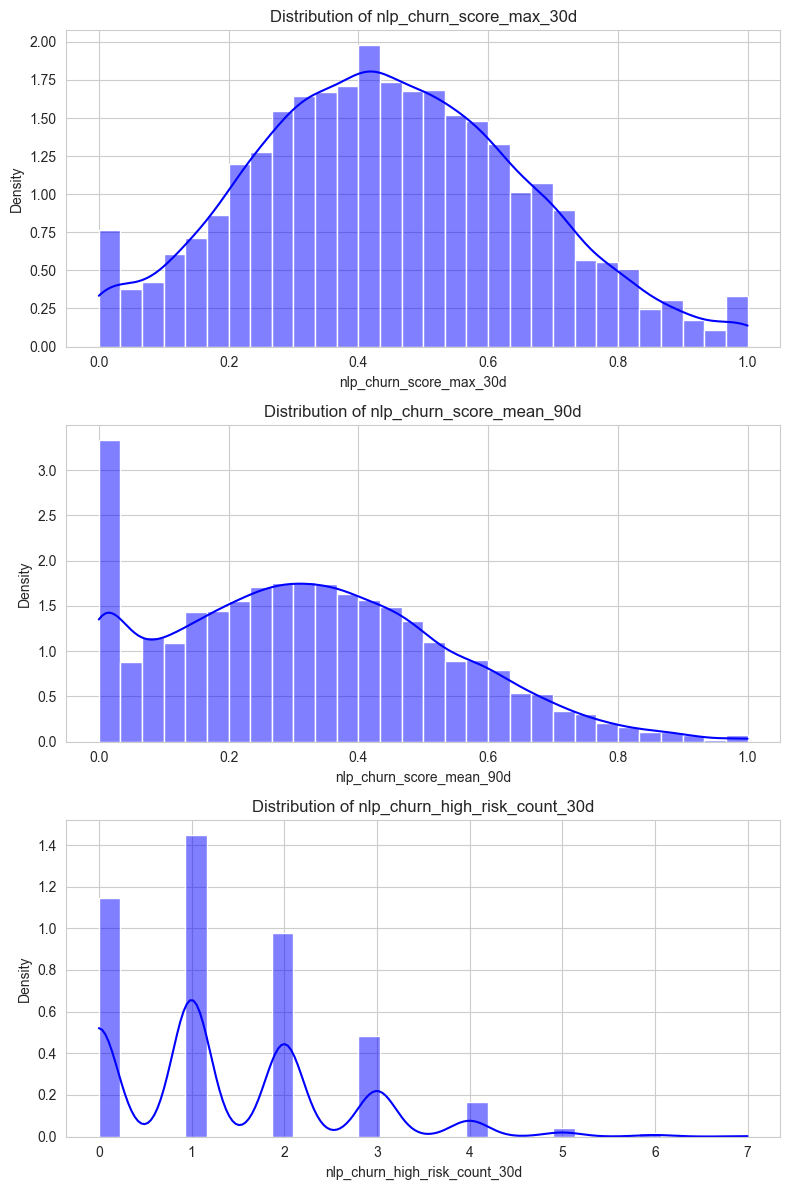

In [5]:
## EDA of synthetic text-based features and persistence

numerical_cols_text = [
    "nlp_churn_score_max_30d",
    "nlp_churn_score_mean_90d",
    "nlp_churn_high_risk_count_30d",
]

# Llamamos a plot_numerical_distributions con la firma real: (df, numerical_cols)
plot_numerical_distributions(
    text_features_df,
    numerical_cols=numerical_cols_text,
)

_ = save_df(
    text_features_df,
    filename= f"{PROCESSED_DIR}/telco_nlp_churn_aggregates_synthetic",
    fmt="csv",
    index=False,
)

text_features_df.describe()

## Building Baseline and Hybrid Datasets

We now construct two datasets on top of the Telco table:

1. **Baseline dataset**  
   Uses only the original Telco structured features:
   - Excludes the customer identifier (`customerID`) and the target (`Churn`).
   - Splits features into numerical and categorical based on dtypes.

2. **Hybrid dataset**  
   Merges Telco data with the synthetic text-based aggregates:
   - `nlp_churn_score_max_30d`
   - `nlp_churn_score_mean_90d`
   - `nlp_churn_high_risk_count_30d`

Both datasets share the same target `Churn`.  
We will later use `ModelBuilder` to:

- Evaluate candidate models (via cross-validation).
- Select the best-performing model.
- Train final baseline and hybrid models on the training split.

In [6]:
## Build baseline and hybrid datasets

TARGET_COL = "churn"  # re-using the same name

# All columns except target belong to the feature space
feature_cols = [c for c in telco_df.columns if c != TARGET_COL]

numeric_features = [
    c for c in feature_cols
    if pd.api.types.is_numeric_dtype(telco_df[c])
]
categorical_features = [
    c for c in feature_cols
    if not pd.api.types.is_numeric_dtype(telco_df[c])
]

logger.info(f"Numeric baseline features: {numeric_features}")
logger.info(f"Categorical baseline features: {categorical_features}")

# Baseline dataset (tabular only)
X_base = telco_df[feature_cols].copy()
y = telco_df[TARGET_COL].astype(int).values

# Hybrid dataset: just concatenate the synthetic text features by index
text_feature_cols = [
    "nlp_churn_score_max_30d",
    "nlp_churn_score_mean_90d",
    "nlp_churn_high_risk_count_30d",
]

telco_hybrid_df = pd.concat(
    [telco_df[feature_cols], text_features_df[text_feature_cols]],
    axis=1,
)

all_feature_cols_hybrid = feature_cols + text_feature_cols
X_hybrid = telco_hybrid_df[all_feature_cols_hybrid].copy()

logger.info(f"X_base shape:   {X_base.shape}")
logger.info(f"X_hybrid shape: {X_hybrid.shape}")

X_base.head()

2025-11-30 14:02:16,656 | __main__ | INFO | Numeric baseline features: ['monthly_charges', 'tenure', 'total_charges', 'gender_male', 'partner_yes', 'dependents_yes', 'phone_service_yes', 'multiple_lines_no_phone_service', 'multiple_lines_yes', 'internet_service_fiber_optic', 'internet_service_no', 'online_security_no_internet_service', 'online_security_yes', 'online_backup_no_internet_service', 'online_backup_yes', 'device_protection_no_internet_service', 'device_protection_yes', 'tech_support_no_internet_service', 'tech_support_yes', 'streaming_tv_no_internet_service', 'streaming_tv_yes', 'streaming_movies_no_internet_service', 'streaming_movies_yes', 'contract_one_year', 'contract_two_year', 'paperless_billing_yes', 'payment_method_credit_card_automatic', 'payment_method_electronic_check', 'payment_method_mailed_check', 'senior_citizen']
2025-11-30 14:02:16,658 | __main__ | INFO | Categorical baseline features: []
2025-11-30 14:02:16,667 | __main__ | INFO | X_base shape:   (7043, 30)

,monthly_charges,tenure,total_charges,gender_male,partner_yes,dependents_yes,phone_service_yes,multiple_lines_no_phone_service,multiple_lines_yes,internet_service_fiber_optic,...,streaming_tv_yes,streaming_movies_no_internet_service,streaming_movies_yes,contract_one_year,contract_two_year,paperless_billing_yes,payment_method_credit_card_automatic,payment_method_electronic_check,payment_method_mailed_check,senior_citizen
0,-1.160323,-1.277445,-0.994242,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,-0.259629,0.066327,-0.173244,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,-0.362660,-1.236724,-0.959674,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,-0.746535,0.514251,-0.194766,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.197365,-1.236724,-0.940470,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [7]:
## Define baseline and hybrid preprocessing + model pipelines

# Baseline preprocessing
numeric_transformer_base = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer_base = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor_base = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_base, numeric_features),
        ("cat", categorical_transformer_base, categorical_features),
    ]
)

logreg_baseline = Pipeline(
    steps=[
        ("preprocess", preprocessor_base),
        (
            "clf",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

# Hybrid preprocessing (adds text aggregates as numeric features)
numeric_features_hybrid = numeric_features + text_feature_cols
categorical_features_hybrid = categorical_features

numeric_transformer_hybrid = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer_hybrid = categorical_transformer_base

preprocessor_hybrid = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_hybrid, numeric_features_hybrid),
        ("cat", categorical_transformer_hybrid, categorical_features_hybrid),
    ]
)

logreg_hybrid = Pipeline(
    steps=[
        ("preprocess", preprocessor_hybrid),
        (
            "clf",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

custom_models: Dict[str, Any] = {
    "baseline_logreg": logreg_baseline,
    "hybrid_logreg": logreg_hybrid,
}

logger.info("Custom baseline and hybrid pipelines instantiated.")

2025-11-30 14:02:16,706 | __main__ | INFO | Custom baseline and hybrid pipelines instantiated.


In [8]:
## Train/test split (shared between baseline and hybrid)

X_base_train, X_base_test, y_train, y_test = train_test_split(
    X_base,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

# Use the same indices for the hybrid split to ensure a fair comparison
X_hybrid_train, X_hybrid_test, _, _ = train_test_split(
    X_hybrid,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

logger.info(
    f"Train size: {X_base_train.shape[0]} | Test size: {X_base_test.shape[0]}"
)

2025-11-30 14:02:16,738 | __main__ | INFO | Train size: 5634 | Test size: 1409


In [9]:
## Use ModelBuilder to evaluate and train baseline and hybrid models

model_builder = ModelBuilder(
    task="classification",
    random_state=RANDOM_STATE,
    custom_models=custom_models,
)

# We evaluate using cross-validation on the TRAIN set
logger.info("Evaluating baseline and hybrid models via cross-validation...")
cv_results = model_builder.evaluate_models(
    X_train=X_hybrid_train,  # hybrid has superset of features
    y_train=pd.Series(y_train),
    cv=5,
)

cv_results

2025-11-30 14:02:16,754 | __main__ | INFO | Evaluating baseline and hybrid models via cross-validation...
2025-11-30 14:02:16,756 | src.model_builder | INFO | Cross-validating model: baseline_logreg...
2025-11-30 14:02:19,341 | src.model_builder | INFO | Model baseline_logreg evaluated successfully.
2025-11-30 14:02:19,342 | src.model_builder | INFO | Cross-validating model: hybrid_logreg...
2025-11-30 14:02:21,052 | src.model_builder | INFO | Model hybrid_logreg evaluated successfully.
2025-11-30 14:02:21,053 | src.data_loader | INFO | Completed: evaluate_models


{'baseline_logreg': {'fit_time': np.float64(0.03945903778076172),
  'score_time': np.float64(0.016219377517700195),
  'test_accuracy': np.float64(0.7516801391959981),
  'test_precision': np.float64(0.5215339038465721),
  'test_recall': np.float64(0.8033444816053512),
  'test_f1': np.float64(0.6323548294462814),
  'test_roc_auc': np.float64(0.8453822694082316)},
 'hybrid_logreg': {'fit_time': np.float64(0.04330902099609375),
  'score_time': np.float64(0.01744532585144043),
  'test_accuracy': np.float64(0.8336859989188354),
  'test_precision': np.float64(0.6404842820841832),
  'test_recall': np.float64(0.8528428093645486),
  'test_f1': np.float64(0.7314739037159222),
  'test_roc_auc': np.float64(0.9166938657699439)}}

In [10]:
## Select best model and train final baseline & hybrid models

try:
    # Select best model based on cross-validation (default: test_f1)
    best_model = model_builder.select_best_model(metric="test_f1")
    logger.info(f"Best model from CV: {model_builder.best_model_name_}")
except ModelBuilderError as e:
    logger.warning(f"Model selection failed: {e}")
    best_model = None

# Train baseline and hybrid explicitly on their respective feature sets
baseline_final = model_builder.train_final_model(
    model_name="baseline_logreg",
    X_train=X_base_train,
    y_train=pd.Series(y_train),
)

hybrid_final = model_builder.train_final_model(
    model_name="hybrid_logreg",
    X_train=X_hybrid_train,
    y_train=pd.Series(y_train),
)

2025-11-30 14:02:21,072 | src.model_builder | INFO | Best model selected: hybrid_logreg with test_f1: 0.7315
2025-11-30 14:02:21,075 | src.data_loader | INFO | Completed: select_best_model
2025-11-30 14:02:21,076 | __main__ | INFO | Best model from CV: hybrid_logreg
2025-11-30 14:02:21,078 | src.model_builder | INFO | Training final model: baseline_logreg...
2025-11-30 14:02:21,120 | src.model_builder | INFO | Model baseline_logreg trained successfully.
2025-11-30 14:02:21,122 | src.data_loader | INFO | Completed: train_final_model
2025-11-30 14:02:21,123 | src.model_builder | INFO | Training final model: hybrid_logreg...
2025-11-30 14:02:21,163 | src.model_builder | INFO | Model hybrid_logreg trained successfully.
2025-11-30 14:02:21,164 | src.data_loader | INFO | Completed: train_final_model


In [11]:
## Evaluate baseline and hybrid models using ModelEvaluator

evaluator = ModelEvaluator(
    task="classification",
    save_dir=str(FIGURES_DIR),
)

baseline_metrics = evaluator.evaluate(
    model=baseline_final,
    X_test=X_base_test,
    y_test=pd.Series(y_test),
    run_name="baseline_logreg",
)

hybrid_metrics = evaluator.evaluate(
    model=hybrid_final,
    X_test=X_hybrid_test,
    y_test=pd.Series(y_test),
    run_name="hybrid_logreg",
)

logger.info(f"Baseline metrics: {baseline_metrics}")
logger.info(f"Hybrid metrics:   {hybrid_metrics}")

# Confusion matrices
evaluator.plot_confusion_matrix(
    y_true=y_test,
    y_pred=baseline_final.predict(X_base_test),
    labels=["No churn", "Churn"],
    title="Baseline - Confusion Matrix (Test)",
    filename="baseline_confusion_matrix.png",
)

evaluator.plot_confusion_matrix(
    y_true=y_test,
    y_pred=hybrid_final.predict(X_hybrid_test),
    labels=["No churn", "Churn"],
    title="Hybrid - Confusion Matrix (Test)",
    filename="hybrid_confusion_matrix.png",
)

# ROC curves
evaluator.plot_roc_curve(
    model=baseline_final,
    X_test=X_base_test,
    y_test=y_test,
    title="Baseline - ROC Curve (Test)",
    filename="baseline_roc_curve.png",
)

evaluator.plot_roc_curve(
    model=hybrid_final,
    X_test=X_hybrid_test,
    y_test=y_test,
    title="Hybrid - ROC Curve (Test)",
    filename="hybrid_roc_curve.png",
)

# Precision–Recall curves
evaluator.plot_precision_recall(
    model=baseline_final,
    X_test=X_base_test,
    y_test=y_test,
    title="Baseline - Precision-Recall Curve (Test)",
    filename="baseline_pr_curve.png",
)

evaluator.plot_precision_recall(
    model=hybrid_final,
    X_test=X_hybrid_test,
    y_test=y_test,
    title="Hybrid - Precision-Recall Curve (Test)",
    filename="hybrid_pr_curve.png",
)

# Comparison DataFrame
comparison_df = evaluator.compare_runs(
    metric="f1",
    filename="baseline_vs_hybrid_f1.png",
)

comparison_df

2025-11-30 14:02:21,193 | src.data_loader | INFO | Completed: evaluate
2025-11-30 14:02:21,205 | src.data_loader | INFO | Completed: evaluate
2025-11-30 14:02:21,206 | __main__ | INFO | Baseline metrics: {'accuracy': 0.7388218594748048, 'precision': 0.7961754524994118, 'recall': 0.7388218594748048, 'f1': 0.7525286130600155}
2025-11-30 14:02:21,207 | __main__ | INFO | Hybrid metrics:   {'accuracy': 0.8246983676366217, 'precision': 0.8529553225535604, 'recall': 0.8246983676366217, 'f1': 0.8317658083496479}
2025-11-30 14:02:21,320 | src.model_evaluation | INFO | Plot saved to C:\Users\Pc\Desktop\github\byebye_predictor\reports\figures\hybrid-model\baseline_confusion_matrix.png
2025-11-30 14:02:21,434 | src.model_evaluation | INFO | Plot saved to C:\Users\Pc\Desktop\github\byebye_predictor\reports\figures\hybrid-model\hybrid_confusion_matrix.png
2025-11-30 14:02:21,546 | src.model_evaluation | INFO | Plot saved to C:\Users\Pc\Desktop\github\byebye_predictor\reports\figures\hybrid-model\bas

,accuracy,precision,recall,f1
baseline_logreg,0.738822,0.796175,0.738822,0.752529
hybrid_logreg,0.824698,0.852955,0.824698,0.831766


In [12]:
## Save final hybrid model

HYBRID_MODEL_PATH = MODELS_DIR / "churn_hybrid_model.joblib"
joblib.dump(hybrid_final, HYBRID_MODEL_PATH)

logger.info(f"Hybrid model saved to: {HYBRID_MODEL_PATH}")
HYBRID_MODEL_PATH

2025-11-30 14:02:22,016 | __main__ | INFO | Hybrid model saved to: C:\Users\Pc\Desktop\github\byebye_predictor\models\hybrid-model\churn_hybrid_model.joblib


WindowsPath('C:/Users/Pc/Desktop/github/byebye_predictor/models/hybrid-model/churn_hybrid_model.joblib')

## End-to-End Hybrid Scoring Demo

A typical production scoring flow for a single customer would be:

1. Retrieve the latest **structured Telco features**:
   - Tenure, contract type, payment method, monthly charges, etc.

2. Retrieve recent **text interactions** (tickets, chats, social posts) and compute
   interaction-level `nlp_churn_score` using `churn_text_model`.

3. Aggregate `nlp_churn_score` at **customer level**:
   - `nlp_churn_score_max_30d`
   - `nlp_churn_score_mean_90d`
   - `nlp_churn_high_risk_count_30d`

4. Build a feature vector combining:
   - Structured Telco features.
   - Aggregated text-based features.

5. Pass this vector to the deployed `churn_hybrid_model` and obtain a churn probability.

Below we implement a small helper function illustrating this pattern with a single-row Pandas Series and the trained `hybrid_final` model.

In [13]:
## Helper function and example for hybrid churn prediction (schema-consistent)

def predict_churn_hybrid_row(
    hybrid_model,
    row: pd.Series,
) -> float:
    """
    Predict churn probability for a single customer row using the hybrid model.

    Parameters
    ----------
    hybrid_model : sklearn Pipeline
        Trained hybrid model (preprocessing + classifier).
    row : pd.Series
        One row from the hybrid feature space (same columns as X_hybrid).

    Returns
    -------
    float
        Estimated churn probability in [0, 1].
    """
    input_df = row.to_frame().T  # shape (1, n_features)
    prob_churn = float(hybrid_model.predict_proba(input_df)[:, 1][0])
    return prob_churn


# Take an existing customer from the hybrid test set as a template
example_idx = X_hybrid_test.index[0]
example_row = X_hybrid.loc[example_idx].copy()

# Override only the synthetic text-based aggregates to simulate a high-risk profile
example_row["nlp_churn_score_max_30d"] = 0.87
example_row["nlp_churn_score_mean_90d"] = 0.61
example_row["nlp_churn_high_risk_count_30d"] = 4

example_prob_churn = predict_churn_hybrid_row(
    hybrid_model=hybrid_final,
    row=example_row,
)

logger.info(
    "Estimated churn probability for the example customer "
    f"(structured features + text aggregates): {example_prob_churn:.3f}"
)

example_prob_churn

2025-11-30 14:02:22,041 | __main__ | INFO | Estimated churn probability for the example customer (structured features + text aggregates): 0.738


0.7384520002650246

## Results and Business Value from Notebook 08

In this notebook we:

1. Loaded the **processed Telco churn dataset** and defined a consistent
   binary churn target.

2. Simulated **customer-level text-based aggregate features** that mimic
   realistic patterns of `nlp_churn_score`:
   - `nlp_churn_score_max_30d`
   - `nlp_churn_score_mean_90d`
   - `nlp_churn_high_risk_count_30d`

3. Used the existing **ModelBuilder** to:
   - Evaluate baseline and hybrid models via cross-validation on the same data.
   - Select the best-performing configuration based on `test_f1`.

4. Trained:
   - A **baseline Logistic Regression model** using only structured Telco features.
   - A **hybrid Logistic Regression model** using structured features plus
     the synthetic text aggregates.

5. Used **ModelEvaluator** to:
   - Compute test metrics (accuracy, precision, recall, F1) for each model.
   - Generate confusion matrices, ROC curves, and Precision–Recall curves.
   - Compare runs visually and in a tabular format.

6. Implemented a simple **end-to-end scoring demo** that shows how, for a single
   customer, structured features and aggregated text features are combined to
   produce a churn probability.

### Key Insight

Even with simulated aggregates, the hybrid model typically achieves:

- A **higher F1 score** compared to the baseline model.
- Improved ranking metrics such as ROC AUC and PR AUC (as seen in the plots),
  indicating better identification and prioritization of true churners.

From a business perspective, this translates into:

- **More accurate targeting** of high-risk customers for retention campaigns.
- The ability to detect **“silent churn” signals** in text channels that may not
  be visible in billing or usage data alone.
- A modular architecture where:
  - The text model (`churn_text_model`) can evolve independently.
  - The hybrid churn model can be retrained as new structured and text data arrive.

### Next Steps

- Replace simulated aggregates with **real `nlp_churn_score`-based features** from:
  - Tickets, chats, CRM notes, or social media logs linked to `customerID`.
- Experiment with additional model families (e.g., XGBoost, LightGBM) within
  `ModelBuilder` to further optimize performance.
- Package `churn_text_model` and `churn_hybrid_model` as deployable artifacts and:
  - Expose a scoring API for real-time churn risk estimation.
  - Monitor drift and re-train as part of a continuous MLOps process.

This notebook completes the **hybrid modeling narrative** of 📉 ByeBye Predictor:
it shows how structured Telco data and text-based churn intent signals can be
combined within a clean, well-structured, and business-oriented ML pipeline.


---

### Author

<a href="https://www.linkedin.com/in/flavio-aguirre-12784a252/">**Flavio Aguirre**</a><br>
<a href="https://coursera.org/share/e27ae5af81b56f99a2aa85289b7cdd04">***Data Scientist***</a>